In [30]:
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec
import seawater as sw
import matplotlib.colors as mcolors
import seawater as gsw
import cartopy.crs as ccrs
from matplotlib.offsetbox import AnchoredText
from shapely.geometry import Polygon
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## Figure S5

In [2]:
inpath = "/gxfs_work/geomar/smomw452/GLORYS12/Data/"
mesh_mask = xr.open_dataset(inpath + "mesh_masks/combined_mesh_mask.nc")
bathy = mesh_mask.hdept.isel(t=0)
land_mask = mesh_mask.tmaskutil.isel(t=0).where(mesh_mask.tmaskutil.isel(t=0) != 0)
lon, lat = mesh_mask.nav_lon, mesh_mask.nav_lat

ds_W = xr.open_mfdataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/Data/W_monthly/*.nc", combine="by_coords"
)

ds_S = xr.open_mfdataset(inpath + "S_monthly/*.nc", combine="by_coords")
ds_T = xr.open_mfdataset(inpath + "T_monthly/*.nc", combine="by_coords")

In [3]:
def select_data(data):
    north_sel = data.isel(y=slice(300, None), x=slice(300, None))
    return north_sel


mesh_mask_slice = select_data(mesh_mask)
bathy_slice = mesh_mask_slice.hdept.isel(t=0)
land_mask_slice = mesh_mask_slice.tmaskutil.isel(t=0).where(
    mesh_mask_slice.tmaskutil.isel(t=0) != 0
)
lon_slice, lat_slice = mesh_mask_slice.nav_lon, mesh_mask_slice.nav_lat

W = select_data(ds_W).vovecrtz

In [5]:
ds_S_slice = select_data(ds_S)
# ds_S_slice.to_netcdf(inpath+'S_data.nc')
ds_T_slice = select_data(ds_T)

S = ds_S_slice.vosaline
T = ds_T_slice.votemper

sigma_ref = (
    xr.apply_ufunc(
        gsw.eos80.dens0, S, T, dask="parallelized", output_dtypes=[np.float64]
    )
    - 1000
)

In [6]:
lon, lat = lon_slice, lat_slice
land_mask = land_mask_slice
bathy = bathy_slice
mesh_mask = mesh_mask_slice


def depth_weighted_mean(S_T_thresh, dim=None):
    diff_z = np.diff(S_T_thresh.deptht)
    dz = np.insert(diff_z, 0, diff_z.mean())
    mask = xr.where(S_T_thresh > -50, 1, np.nan)
    dz_masked = dz[None, :, None, None] * mask
    dz_sum_masked = dz_masked.sum(dim="deptht")
    # making mask of ones and nans -- mask changes per year (ones and nans) since depth changes per year
    weighted_depth_mean = (S_T_thresh * dz_masked).sum(
        dim="deptht"
    ).squeeze() / dz_sum_masked
    # weighted_depth_mean_ts = weighted_depth_mean.mean(dim=dim)
    return weighted_depth_mean


def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return fit, da - fit

In [ ]:
target_density = 28
depth_of_interest = xr.where(sigma_ref >= target_density, 1, np.nan).idxmin("deptht")

W_600_1300m_mean = depth_weighted_mean(
    W.rename({"depthw": "deptht"}).sel(deptht=slice(600, 1300))
)
W_600_1300m_mean = W_600_1300m_mean.where(W_600_1300m_mean < 1e20)

sig_ref_mean = sigma_ref.mean(dim="time_counter").compute()
mean_z_interest = depth_of_interest.mean(dim="time_counter").compute()

In [19]:
W_at_depth_of_interest = W.sel(depthw=mean_z_interest, method="nearest")
W_at_depth_of_interest_mean = W_at_depth_of_interest.mean(dim="time_counter").compute()

W_at_depth_of_interest_mean = W_at_depth_of_interest_mean.where(
    W_at_depth_of_interest_mean < 1e20
)

mask = (mean_z_interest > 20) & (mean_z_interest < 0.9 * bathy)

W_masked = W_at_depth_of_interest_mean.where(mask)

# assume W_masked is (y, x)
W_smooth = W_masked.rolling(
    y=10,  # number of gridpoints in y
    x=10,  # number of gridpoints in x
    center=True,
).mean()

In [9]:
mean_z_interest = xr.open_dataset("netcdfs/mean_z_28_isopycnal.nc").deptht

In [12]:
# Define the vertices based on the lines you've plotted
vertices = [
    (-12, 74.5),  # Start point of the first line
    (-2.5, 76.7),  # End point of the first line / Start point of the second line
    (4, 74),  # End point of the second line / Start point of the third line
    (-1, 73),  # End point of the third line / Start point of the fourth line
    (-12, 73),  # End point of the fourth line / Start point of the fifth line
    (-12, 74.5),  # Closing the polygon back to the start point
]

# Create a Shapely polygon
polygon_Gsea = Polygon(vertices)

# Extract the x and y coordinates for plotting
x_GSea, y_GSea = polygon_Gsea.exterior.xy

vertices = [
    (-4.5, 70.7),  # Start point of the first line
    (2, 68.6),  # End point of the first line / Start point of the second line
    (9, 68.6),  # End point of the second line / Start point of the third line
    (14, 69.6),  # End point of the third line / Start point of the fourth line
    (6, 72.5),  # End point of the fourth line / Start point of the fifth line
    (-4.5, 70.7),  # Closing the polygon back to the start point
]

# Create a Shapely polygon
polygon_Lofoten = Polygon(vertices)

# Extract the x and y coordinates for plotting
x_Lofoten, y_Lofoten = polygon_Lofoten.exterior.xy

# Define the vertices of the square based on the latitude and longitude limits
vertices = [
    (-13.5, 70),  # Top left vertex -14
    (-9.2, 70),  # Top right vertex
    (-9.2, 67.5),  # Bottom right vertex
    (-13.5, 67.5),  # Bottom left vertex
]

# Create a Shapely polygon
polygon_Iceland = Polygon(vertices)

# Get the x and y coordinates of the polygon's exterior
x_Iceland, y_Iceland = polygon_Iceland.exterior.xy

vertices = [
    (-6.2, 64),
    (
        -6.2,
        69.5,
    ),  # Start point of the first line# End point of the first line / Start point of the second line
    (-3, 69.5),  # End point of the second line / Start point of the third line
    (1, 67.5),  # End point of the third line / Start point of the fourth line
    (1, 64),  # End point of the fourth line / Start point of the fifth line
    (-6.2, 64),  # Closing the polygon back to the start point
]

# Create a Shapely polygon
polygon_Norwegian = Polygon(vertices)

# Extract the x and y coordinates for plotting
x_Norwegian, y_Norwegian = polygon_Norwegian.exterior.xy

In [14]:
contour_interval = 700

contour_levels = np.arange(
    np.floor(bathy.min() / contour_interval) * contour_interval,
    np.ceil(bathy.max() / contour_interval) * contour_interval,
    contour_interval,
)

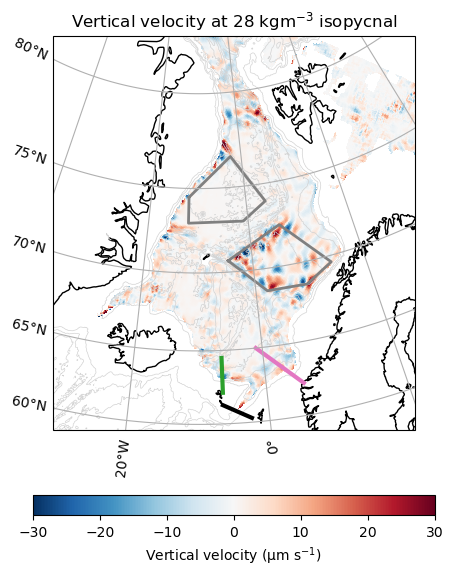

In [20]:
proj = ccrs.LambertConformal(central_longitude=-10, central_latitude=70)
fig, ax = plt.subplots(1, 1, figsize=(7, 6), subplot_kw={"projection": proj})
# ax.set_extent([-18, 7, 59, 80], crs=ccrs.PlateCarree())
ax.set_extent([-30, 20, 59, 82], crs=ccrs.PlateCarree())
ax.coastlines()
ax.contour(
    mesh_mask.nav_lon,
    mesh_mask.nav_lat,
    bathy,
    levels=contour_levels,
    colors="lightgray",
    linewidths=0.5,
    alpha=1,
    transform=ccrs.PlateCarree(),
)

m = ax.pcolormesh(
    lon,
    lat,
    W_smooth * 1e6,
    cmap="RdBu_r",
    vmin=-30,
    vmax=30,
    transform=ccrs.PlateCarree(),
)

fig.colorbar(m, ax=ax, orientation="horizontal", pad=0.12, shrink=0.6).set_label(
    "Vertical velocity (μm s$^{-1}$)"
)

ax.plot(
    [-6.5, -2.5], [61.3, 60.3], color="k", transform=ccrs.PlateCarree(), linewidth=3
)
ax.plot(
    [-6.43, -6.43],
    [62.15, 64.5],
    color="tab:green",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax.plot(
    [5.5, -1],
    [62.24, 65.0],
    color="tab:pink",
    transform=ccrs.PlateCarree(),
    linewidth=3,
)
ax.plot(x_GSea, y_GSea, color="gray", linewidth=2, transform=ccrs.PlateCarree())
ax.plot(x_Lofoten, y_Lofoten, color="gray", linewidth=2, transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
gl.xlabels_top = False
gl.ylabels_right = False

ax.set_title("Vertical velocity at 28 kgm$^{-3}$ isopycnal")
plt.tight_layout()
# plt.savefig('vertical_velocity.png',dpi=300, bbox_inches="tight")
plt.show()

## Figure S6

In [ ]:
MLD = xr.open_mfdataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/Data/MLD_monthly/somxl010_*.nc",
    combine="by_coords",
).somxl010

mesh_mask = xr.open_dataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/Data/mesh_masks/combined_mesh_mask.nc"
)

z = mesh_mask.e3t_0
t_mask = mesh_mask.tmask

# bathymetry (Depth level) at every grid point
bathymetry = (z * t_mask).isel(t=0).sum(dim="z")

# turn zeros into nans, easier to see where continents are
bath_total_nans = bathymetry.where(bathymetry != 0)
land_mask = mesh_mask.tmask.where(mesh_mask.tmask != 0).isel(t=0, z=0)


def select_data(data):
    north_sel = data.isel(y=slice(300, None), x=slice(300, None))
    return north_sel


MLD = select_data(MLD)

mesh_mask = select_data(mesh_mask)
bathymetry = select_data(bathymetry)
land_mask = select_data(land_mask)


S = select_data(ds_S).vosaline
T = select_data(ds_T).votemper

# sigma0 = xr.apply_ufunc(gsw.eos80.pden,S,T,0,dask='parallelized',output_dtypes=[np.float64]) - 1000

# grid cell area
dx = mesh_mask.e1t.isel(
    t=0
)  # .assign_coords({"nav_lon": S.nav_lon,"nav_lat": S.nav_lat})

dy = mesh_mask.e2t.isel(
    t=0
)  # .assign_coords({"nav_lon": S.nav_lon,"nav_lat": S.nav_lat})
grid_cell_area = mesh_mask.e1t.isel(t=0) * mesh_mask.e2t.isel(t=0)

total_area = grid_cell_area.sum(["y", "x"])

bathymetry = bathymetry.assign_coords(
    {"nav_lon": mesh_mask.nav_lon, "nav_lat": mesh_mask.nav_lat}
)

mask_lofoten_bathy = xr.where(bathymetry > 3000, 1, np.nan).where(
    (bathymetry.nav_lat > 68)
    & (bathymetry.nav_lat < 72.5)
    & (bathymetry.nav_lon > -5)
    & (bathymetry.nav_lon < 15),
    drop=False,
)

mask_grnl_sea_bathy = xr.where(bathymetry > 3000, 1, np.nan).where(
    (bathymetry.nav_lat > 72)
    & (bathymetry.nav_lat < 78.5)
    & (bathymetry.nav_lon > -12.5)
    & (bathymetry.nav_lon < 6.5),
    drop=False,
)

In [4]:
def calculate_slope_intercept(x1, y1, x2, y2):
    """Calculate the slope (m) and y-intercept (b) of a line."""
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b


m, b = calculate_slope_intercept(-5, 70.5, 2, 68.2)
m1, b1 = calculate_slope_intercept(-5, 71, 5, 72.5)

m_gsea, b_gsea = calculate_slope_intercept(-1, 72.1, 7, 73.5)
ds_window1 = (mask_lofoten_bathy.nav_lat >= mask_lofoten_bathy.nav_lon * m + b).astype(
    int
)
ds_window2 = (
    mask_lofoten_bathy.nav_lat <= mask_lofoten_bathy.nav_lon * m1 + b1
).astype(int)

# mask the basins

mask_lofoten = (ds_window1 * ds_window2 * mask_lofoten_bathy).where(
    ds_window1 * ds_window2 * mask_lofoten_bathy != 0
)

ds_window_gsea = (
    mask_grnl_sea_bathy.nav_lat >= mask_grnl_sea_bathy.nav_lon * m_gsea + b_gsea
).astype(int)
mask_grnl_sea = (ds_window_gsea * mask_grnl_sea_bathy).where(
    ds_window_gsea * mask_grnl_sea_bathy != 0
)

In [7]:
sigma0 = (
    xr.apply_ufunc(
        gsw.eos80.pden, S, T, 0, dask="parallelized", output_dtypes=[np.float64]
    )
    - 1000
)

In [8]:
sigma0_lofoten = sigma0 * mask_lofoten
sigma0_grnl_sea = sigma0 * mask_grnl_sea


def weighted_time_series(masked_variable):
    m = masked_variable[0, :, :] * 0 + 1  # 2d mask of ones and nans
    w = grid_cell_area / total_area
    w_mask = m * w
    w = w_mask / np.nansum(w_mask)
    new_weights = (masked_variable * w).sum(("y", "x"))
    # print(new_weights.shape)
    new_weights = new_weights
    return new_weights

In [18]:
MLD_hovmoller_lofoten = weighted_time_series(MLD * mask_lofoten).compute()
MLD_hovmoller_grnl_sea = weighted_time_series(MLD * mask_grnl_sea).compute()

MLD_hovmoller_lofoten = MLD_hovmoller_lofoten.sel(time_counter=slice(None, "2020"))
MLD_hovmoller_grnl_sea = MLD_hovmoller_grnl_sea.sel(time_counter=slice(None, "2020"))

In [9]:
ds = xr.open_dataset(
    "/gxfs_work/geomar/smomw452/GLORYS12/GLORYS_data_download_scripts/hovmollers_Lofoten_GSea.nc"
)

S_hovmoller_lofoten = ds["S_lofoten"]
T_hovmoller_lofoten = ds["T_lofoten"]
S_hovmoller_grnl_sea = ds["S_grnl_sea"]
T_hovmoller_grnl_sea = ds["T_grnl_sea"]

In [16]:
# Custom colormap: darker blues, white at center, deep reds
colors_temp = [
    "#081d58",  # very dark navy
    "#08306b",  # dark blue
    "#08519c",  # deep blue
    "#2171b5",  # medium blue
    "#ffffff",  # white at -0.8 °C
    "#fb6a4a",  # red
    "#cb181d",  # dark red
    "#67000d",  # very dark red
]
cmap_temp = mcolors.LinearSegmentedColormap.from_list("cmap_temp", colors_temp)

# Normalization: center white at -0.8 °C
norm_temp = mcolors.TwoSlopeNorm(vmin=-1.8, vcenter=-0.9, vmax=0.8)

# Meshgrid for contourf (time vs depth)
time = S_hovmoller_grnl_sea.time_counter.values
depth = -S_hovmoller_grnl_sea.deptht.values  # negative for depth downwards
temp = T_hovmoller_grnl_sea.T.values

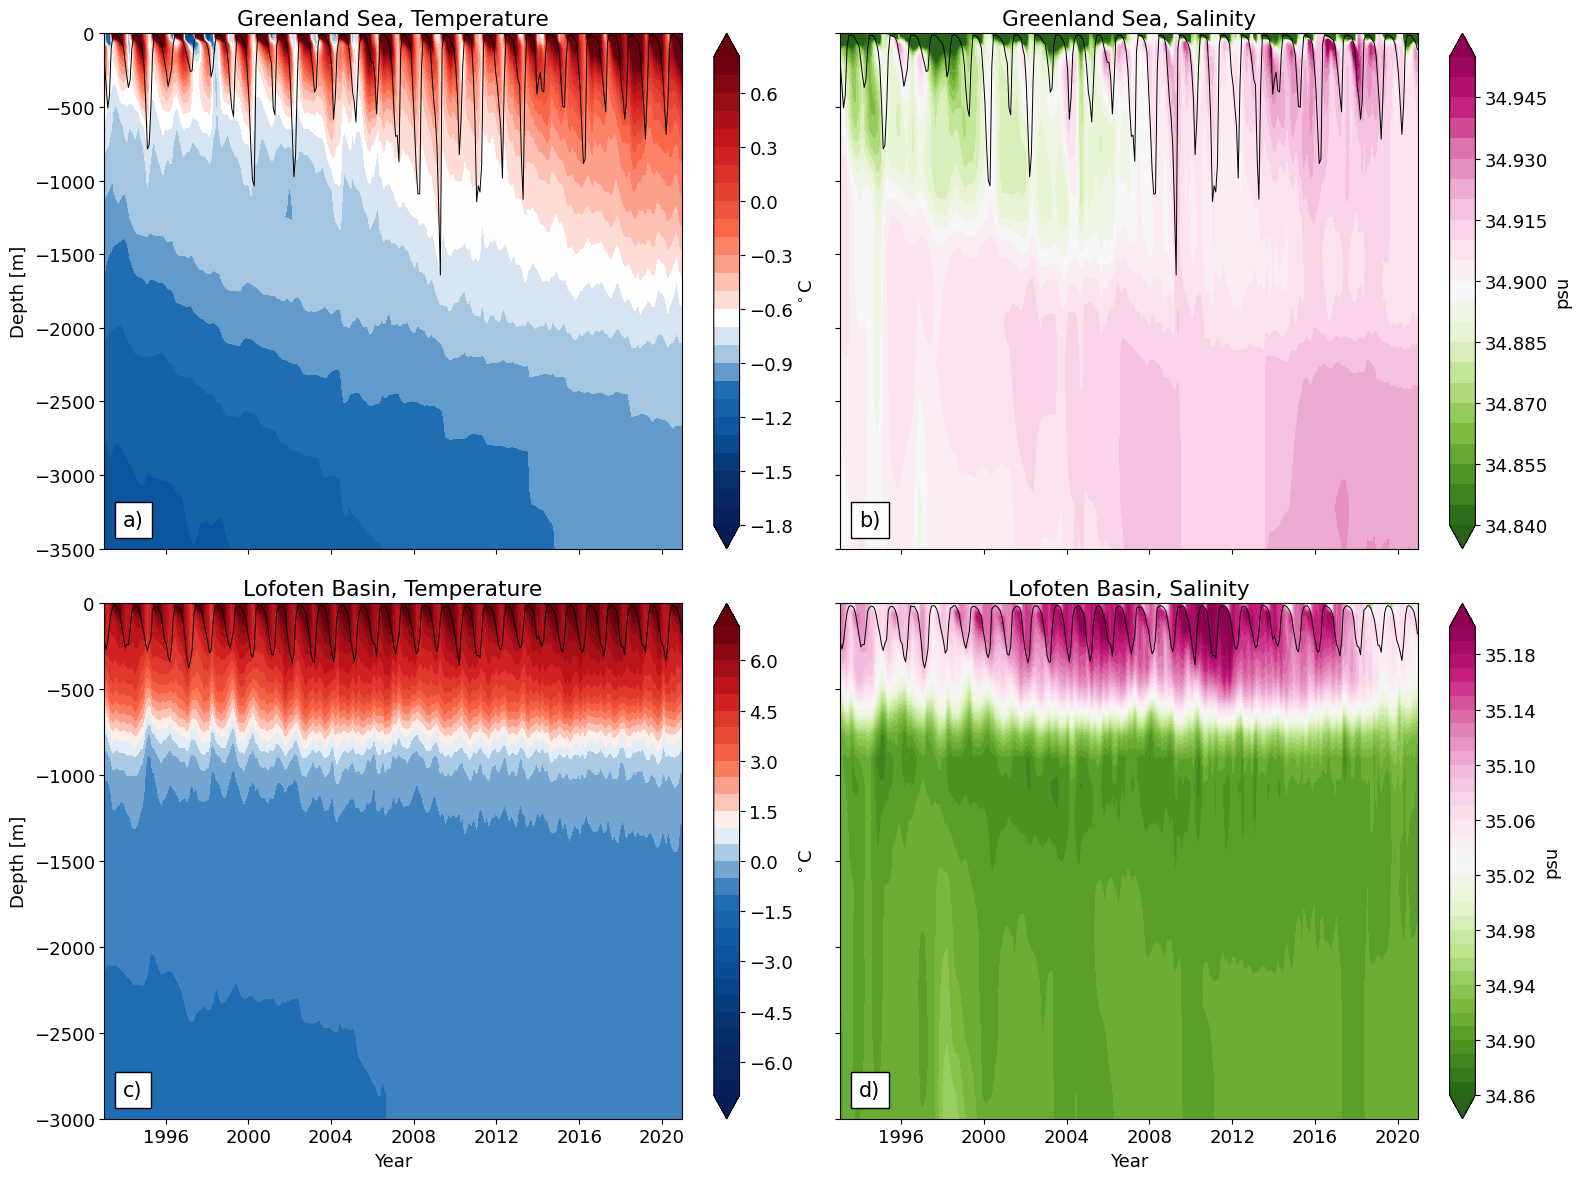

In [21]:
plt.rcParams.update({"font.size": 13})

time_grnl = S_hovmoller_grnl_sea.time_counter.values
depth_grnl = -S_hovmoller_grnl_sea.deptht.values
temp_grnl = T_hovmoller_grnl_sea.T.values

# Colormap
cmap_temp = mcolors.LinearSegmentedColormap.from_list("cmap_temp", colors_temp)
norm_lof = mcolors.TwoSlopeNorm(vmin=-7, vcenter=0, vmax=7)
levels_lof = np.arange(-7, 7.1, 0.5)

# Normalize: center white at -1.05 °C
norm_grnl = mcolors.TwoSlopeNorm(vmin=-1.8, vcenter=-0.9, vmax=0.8)  # vcenter = -1.05
levels_grnl = np.arange(-1.8, 0.81, 0.1)

# -------------------
# Greenland Sea Salinity
# -------------------
sali_grnl = S_hovmoller_grnl_sea.values
levels_sali_grnl = np.arange(34.84, 34.96, 0.005)

# -------------------
# Lofoten Basin Salinity
# -------------------
sali_lof = S_hovmoller_lofoten.values
levels_sali_lof = np.arange(34.86, 35.2, 0.01)

# -------------------
# Lofoten Basin
# -------------------
time_lof = T_hovmoller_lofoten.time_counter.values
depth_lof = -T_hovmoller_lofoten.deptht.values
temp_lof = T_hovmoller_lofoten.T.values


fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)

# Greenland Sea Temperature Plot
cf1 = axes[0, 0].contourf(
    time_grnl,
    depth_grnl,
    temp_grnl,
    levels=levels_grnl,
    cmap=cmap_temp,
    norm=norm_grnl,
    extend="both",
)
axes[0, 0].plot(time_grnl, -MLD_hovmoller_grnl_sea, "k", linewidth=0.7)
axes[0, 0].set_ylim(-3500, 0)
axes[0, 0].set_ylabel("Depth [m]")
axes[0, 0].set_title("Greenland Sea, Temperature")  # comma added
cbar1 = fig.colorbar(
    cf1, ax=axes[0, 0], orientation="vertical", fraction=0.05, pad=0.05
)
cbar1.set_label(r"$^\circ$C")  # minimal label
axes[0, 0].add_artist(
    AnchoredText("a)", prop=dict(size=15), frameon=True, loc="lower left")
)

# Greenland Sea Salinity Plot
cf3 = axes[0, 1].contourf(
    time_grnl,
    depth_grnl,
    sali_grnl.T,
    levels=levels_sali_grnl,
    cmap="PiYG_r",
    extend="both",
)
axes[0, 1].plot(time_grnl, -MLD_hovmoller_grnl_sea, "k", linewidth=0.7)
axes[0, 1].set_ylim(-3500, 0)
axes[0, 1].set_title("Greenland Sea, Salinity")  # comma added
axes[0, 1].set_ylabel("")  # remove label
axes[0, 1].set_yticklabels([])  # remove tick labels
cbar3 = fig.colorbar(
    cf3, ax=axes[0, 1], orientation="vertical", fraction=0.05, pad=0.05
)
cbar3.set_label(r"psu")
axes[0, 1].add_artist(
    AnchoredText("b)", prop=dict(size=15), frameon=True, loc="lower left")
)

# Lofoten Basin Temperature Plot
cf2 = axes[1, 0].contourf(
    time_lof,
    depth_lof,
    temp_lof,
    levels=levels_lof,
    cmap=cmap_temp,
    norm=norm_lof,
    extend="both",
)
axes[1, 0].plot(time_lof, -MLD_hovmoller_lofoten, "k", linewidth=0.7)
axes[1, 0].set_ylim(-3000, 0)
axes[1, 0].set_ylabel("Depth [m]")
axes[1, 0].set_title("Lofoten Basin, Temperature")  # comma added
cbar2 = fig.colorbar(
    cf2, ax=axes[1, 0], orientation="vertical", fraction=0.05, pad=0.05
)
cbar2.set_label(r"$^\circ$C")  # minimal label
axes[1, 0].add_artist(
    AnchoredText("c)", prop=dict(size=15), frameon=True, loc="lower left")
)

# Lofoten Basin Salinity Plot
cf4 = axes[1, 1].contourf(
    time_lof,
    depth_lof,
    sali_lof.T,
    levels=levels_sali_lof,
    cmap="PiYG_r",
    extend="both",
)
axes[1, 1].plot(time_lof, -MLD_hovmoller_lofoten, "k", linewidth=0.7)
axes[1, 1].set_ylim(-3000, 0)
axes[1, 1].set_title("Lofoten Basin, Salinity")  # comma added
axes[1, 1].set_ylabel("")  # remove label
axes[1, 1].set_yticklabels([])  # remove tick labels
cbar4 = fig.colorbar(
    cf4, ax=axes[1, 1], orientation="vertical", fraction=0.05, pad=0.05
)
cbar4.set_label(r"psu")
axes[1, 1].add_artist(
    AnchoredText("d)", prop=dict(size=15), frameon=True, loc="lower left")
)

for ax in axes[1, :]:
    ax.set_xlabel("Year")

plt.tight_layout()
# plt.savefig('S2', bbox_inches='tight', dpi=300)
plt.show()

## Figure S7

In [26]:
## N sections high versus low transport

N = xr.open_dataset("/gxfs_work/geomar/smomw452/GLORYS12/Data/N_section.nc")
N_sigma0 = (
    xr.apply_ufunc(
        sw.eos80.dens0,
        N.vosaline,
        N.votemper,
        dask="parallelized",
        output_dtypes=[np.float64],
    )
    - 1000
)
N_overflow = N.where(N_sigma0 > 28)


# high trspt
input_date_2003 = "2002-09-01", "2003-07-01"
input_date_2009 = "2009-11-01", "2010-09-01"
input_date_1997 = "1997-11-01", "1998-09-01"

# low trspt
input_date_2012 = "2011-09-01", "2012-07-01"
input_date_1999 = "1999-01-01", "1999-12-01"
input_date_2014 = "2014-12-01", "2015-10-01"


# get mean fields
vel_2003 = N.u_rot_normal.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)
sal_2003 = N.vosaline.sel(time_counter=slice(*input_date_2003)).mean(dim="time_counter")
temp_2003 = N.votemper.sel(time_counter=slice(*input_date_2003)).mean(
    dim="time_counter"
)
sigma_2003 = N_sigma0.sel(time_counter=slice(*input_date_2003)).mean(dim="time_counter")

vel_2009 = N.u_rot_normal.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)
sal_2009 = N.vosaline.sel(time_counter=slice(*input_date_2009)).mean(dim="time_counter")
temp_2009 = N.votemper.sel(time_counter=slice(*input_date_2009)).mean(
    dim="time_counter"
)
sigma_2009 = N_sigma0.sel(time_counter=slice(*input_date_2009)).mean(dim="time_counter")

vel_1997 = N.u_rot_normal.sel(time_counter=slice(*input_date_1997)).mean(
    dim="time_counter"
)
sal_1997 = N.vosaline.sel(time_counter=slice(*input_date_1997)).mean(dim="time_counter")
temp_1997 = N.votemper.sel(time_counter=slice(*input_date_1997)).mean(
    dim="time_counter"
)


vel_2012 = N.u_rot_normal.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)
sal_2012 = N.vosaline.sel(time_counter=slice(*input_date_2012)).mean(dim="time_counter")
temp_2012 = N.votemper.sel(time_counter=slice(*input_date_2012)).mean(
    dim="time_counter"
)
sigma_2012 = N_sigma0.sel(time_counter=slice(*input_date_2012)).mean(dim="time_counter")


def high_trspt(data):
    slices_high_trspt = [
        data.sel(time_counter=slice(*input_date_1997)),
        data.sel(time_counter=slice(*input_date_2003)),
        data.sel(time_counter=slice(*input_date_2009)),
    ]
    return slices_high_trspt


def low_trspt(data):
    slices_low_trspt = [
        data.sel(time_counter=slice(*input_date_2012)),
        data.sel(time_counter=slice(*input_date_1999)),
        data.sel(time_counter=slice(*input_date_2014)),
    ]
    return slices_low_trspt


high_trspt_N = xr.concat(high_trspt(N), dim="time_counter").mean(dim="time_counter")

high_trspt_sigma_N = xr.concat(high_trspt(N_sigma0), dim="time_counter").mean(
    dim="time_counter"
)

low_trspt_N = xr.concat(low_trspt(N), dim="time_counter").mean(dim="time_counter")
low_trspt_sigma_N = xr.concat(low_trspt(N_sigma0), dim="time_counter").mean(
    dim="time_counter"
)

# Difference
vel_diff_N = high_trspt_N.u_rot_normal - low_trspt_N.u_rot_normal
sal_diff_N = high_trspt_N.vosaline - low_trspt_N.vosaline
temp_diff_N = high_trspt_N.votemper - low_trspt_N.votemper


cmap_vel = plt.get_cmap("bwr")
cmap_vel.set_bad(color="gray")

cmap_sal = plt.get_cmap("PuOr_r")
cmap_sal.set_bad(color="gray")


cmap_temp = plt.get_cmap("RdBu_r")
cmap_temp.set_bad(color="gray")

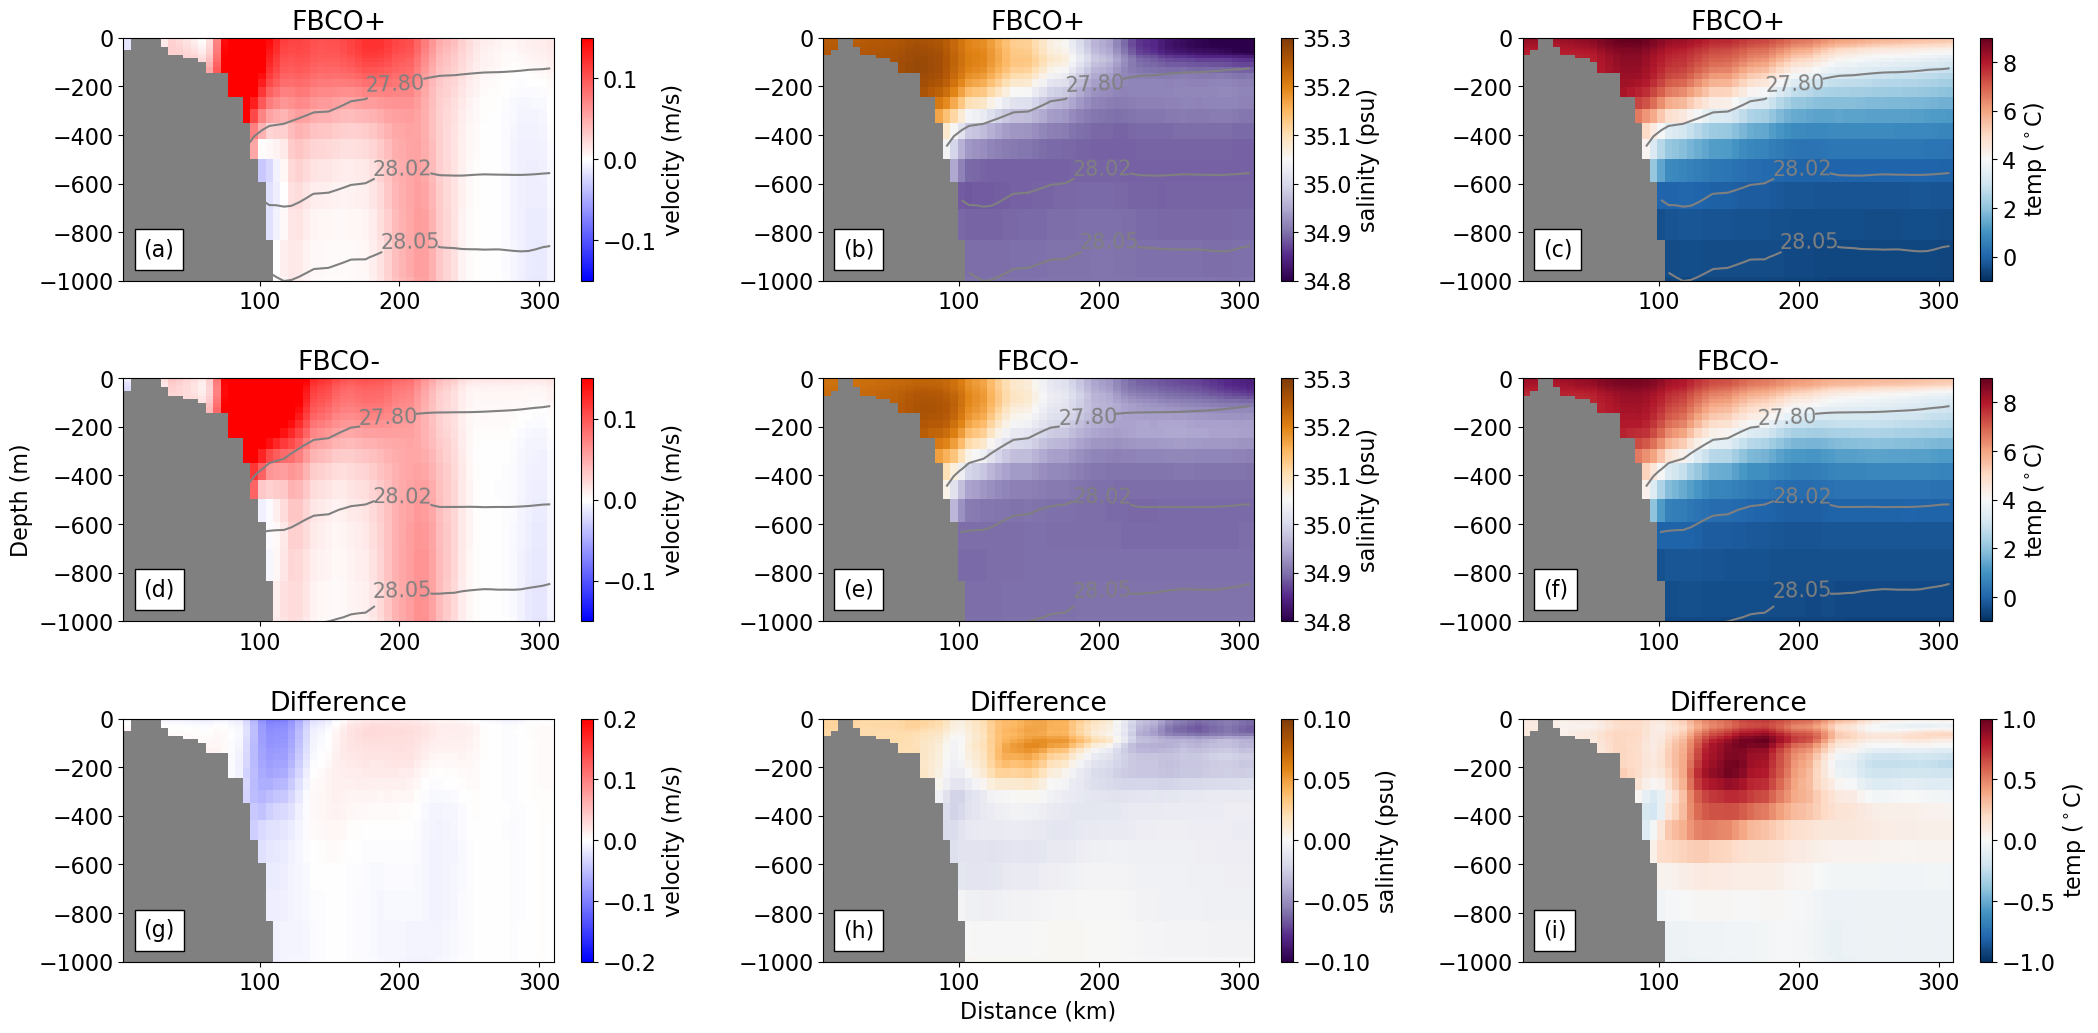

In [27]:
plt.rcParams.update({"font.size": 16})

# === Figure layout ===
fig = plt.figure(figsize=(25, 12))
gs = gridspec.GridSpec(3, 3, height_ratios=[2.5, 2.5, 2.5], hspace=0.4, wspace=0.3)

# Panel labels
labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]
label_idx = 0

# === 3x3 section plots ===
for row, (vel, sal, temp, sigma, label, diff_flag) in enumerate(
    [
        (
            high_trspt_N.u_rot_normal,
            high_trspt_N.vosaline,
            high_trspt_N.votemper,
            high_trspt_sigma_N,
            "FBCO+",
            False,
        ),
        (
            low_trspt_N.u_rot_normal,
            low_trspt_N.vosaline,
            low_trspt_N.votemper,
            low_trspt_sigma_N,
            "FBCO-",
            False,
        ),
        (
            vel_diff_N,
            sal_diff_N,
            temp_diff_N,
            None,
            "Difference",
            True,
        ),
    ]
):
    for col, (data, cmap, vmin, vmax, varname) in enumerate(
        [
            (
                vel,
                cmap_vel,
                -0.2 if diff_flag else -0.15,
                0.2 if diff_flag else 0.15,
                "velocity (m/s)",
            ),
            (
                sal,
                cmap_sal,
                -0.1 if diff_flag else 34.8,
                0.1 if diff_flag else 35.3,
                "salinity (psu)",
            ),
            (
                temp,
                cmap_temp,
                -1.0 if diff_flag else -1,
                1.0 if diff_flag else 9,
                r"temp ($^\circ$C)",
            ),
        ]
    ):
        ax = fig.add_subplot(gs[row, col])
        pc = ax.pcolormesh(N.c / 1e3, -N.z, data, cmap=cmap, vmin=vmin, vmax=vmax)

        # Add density contours for non-difference plots
        if not diff_flag and sigma is not None:
            CS = ax.contour(
                N.c / 1e3,
                -N.z,
                sigma,
                [27.8, 28.02, 28.05, 28.06, 28.07, 28.08],
                colors="gray",
            )
            ax.clabel(CS, inline=True, fontsize=15)

        # ax.set_xlabel("distance (km)")
        # if col == 0:
        #     ax.set_ylabel("depth (m)")
        # Axis labels:
        if label_idx == 3:
            ax.set_ylabel("Depth (m)")
        else:
            ax.set_ylabel("")

        # distance label on panel (h)
        if label_idx == 7:
            ax.set_xlabel("Distance (km)")
        else:
            ax.set_xlabel("")

        ax.set_ylim(-1000, 0)
        ax.set_title(label)
        fig.colorbar(pc, ax=ax).set_label(varname)

        # Add anchored label (panel letter)
        at = AnchoredText(
            labels[label_idx], loc="lower left", prop=dict(size=16), frameon=True
        )
        ax.add_artist(at)
        label_idx += 1
plt.tight_layout()
# plt.savefig('S7',dpi=300,bbox_inches='tight')
plt.show()